# Modelling

In [1]:
# Colab — install dependencies
!pip install lightgbm duckdb -q

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

MessageError: User cancelled dfs_ephemeral authorization

## 1. Setup & Data Preparation

In [2]:
import duckdb
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

con = duckdb.connect(
    database='/content/drive/MyDrive/UNI/credit_risk/credit_risk.duckdb',
    read_only=True
)
#con = duckdb.connect(database='data/credit_risk.duckdb', read_only=True)
print("Connected.")

Connected.


In [3]:
# Load train and test into pandas for sklearn/LightGBM
df_train = con.execute("SELECT * FROM app_train_final_v3").fetchdf()
df_test  = con.execute("SELECT * FROM app_test_final").fetchdf()

print(f"Train : {df_train.shape}")
print(f"Test  : {df_test.shape}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train : (307511, 269)
Test  : (48744, 269)


In [4]:
# ── Define column groups ──────────────────────────────────────────────
TARGET_COL    = 'TARGET'
ID_COL        = 'SK_ID_CURR'

# High-cardinality string columns — target encoded inside k-fold
TE_COLS       = ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

# Columns to exclude from features entirely
EXCLUDE_COLS  = [TARGET_COL, ID_COL, 'PREV_LAST_STATUS'] + TE_COLS

# Final numeric feature list
FEATURE_COLS  = [
    c for c in df_train.columns
    if c not in EXCLUDE_COLS
    and df_train[c].dtype != object
]

print(f"Feature columns   : {len(FEATURE_COLS)}")
print(f"Target encode cols: {TE_COLS}")
print(f"Target distribution:\n{df_train[TARGET_COL].value_counts(normalize=True).round(4)}")

Feature columns   : 264
Target encode cols: ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
Target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


In [5]:
# ── Separate X, y, ids ────────────────────────────────────────────────
X       = df_train[FEATURE_COLS + TE_COLS].copy()
y       = df_train[TARGET_COL].copy()
ids     = df_train[ID_COL].copy()

X_test  = df_test[FEATURE_COLS + TE_COLS].copy()
ids_test = df_test[ID_COL].copy()

print(f"X train : {X.shape}")
print(f"X test  : {X_test.shape}")
print(f"Positive rate: {y.mean():.4f}")

X train : (307511, 266)
X test  : (48744, 266)
Positive rate: 0.0807


In [6]:
# ── Sanity checks ─────────────────────────────────────────────────────
print("Data quality checks\n")

# INF values
inf_cols = [c for c in FEATURE_COLS
            if np.isinf(df_train[c].replace([np.inf, -np.inf], np.nan)).any()]
print(f"Columns with INF  : {inf_cols if inf_cols else 'None ✓'}")

# Constant columns (zero variance)
const_cols = [c for c in FEATURE_COLS if df_train[c].nunique() <= 1]
print(f"Constant columns  : {const_cols if const_cols else 'None ✓'}")

# Missing rate summary
missing = X[FEATURE_COLS].isnull().mean()
print(f"\nMissing rate summary:")
print(f"  Columns with 0% missing   : {(missing == 0).sum()}")
print(f"  Columns with <10% missing : {(missing < 0.1).sum()}")
print(f"  Columns with >50% missing : {(missing > 0.5).sum()}")
print(f"  Max missing rate          : {missing.max():.2%}  ({missing.idxmax()})")

Data quality checks

Columns with INF  : None ✓
Constant columns  : None ✓

Missing rate summary:
  Columns with 0% missing   : 86
  Columns with <10% missing : 163
  Columns with >50% missing : 50
  Max missing rate          : 98.50%  (PREV_INTEREST_RATE_MEAN)


In [7]:
# ── Replace INF with NaN if any found ────────────────────────────────
# LightGBM cannot handle INF — NaN is handled natively
X      = X.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
print("INF values replaced with NaN.")

INF values replaced with NaN.


## Baseline Model — LightGBM

Establishes the performance floor before any tuning.
All subsequent improvements are measured against this baseline.

**Setup:**
- Algorithm: LightGBM binary classifier
- Validation: Stratified 5-fold cross-validation
- Metric: AUC-ROC (Kaggle evaluation metric)
- Class imbalance: handled via `scale_pos_weight = 11.4` (ratio of negatives to positives)
- Target encoding: `OCCUPATION_TYPE` and `ORGANIZATION_TYPE` fitted on train
  folds only — never on the full dataset — to prevent leakage

**Results:**

| Fold | AUC |
|---|---|
| 1 | 0.78861 |
| 2 | 0.78414 |
| 3 | 0.79065 |
| 4 | 0.78573 |
| 5 | 0.78538 |
| **OOF AUC** | **0.78685** |
| Std | 0.00238 |

**Observations:**
- OOF AUC of 0.787 is already above the public median (~0.74-0.75)
  with default parameters — a direct result of the feature engineering investment
- Low fold std (0.0024) confirms the model generalises consistently across splits
- Early stopping triggered between iterations 230-333 across folds —
  no underfitting signal

In [8]:
# ── Target encoding function ──────────────────────────────────────────
# Defined here, called inside the k-fold loop

def target_encode(X_train, y_train, X_val, cols, smooth=20):
    X_train_enc = X_train.copy()
    X_val_enc   = X_val.copy()
    global_mean = y_train.mean()
    encodings   = {}

    for col in cols:
        stats = (
            X_train_enc[[col]]
            .assign(target=y_train.values)
            .groupby(col)['target']
            .agg(['mean', 'count'])
        )
        stats['smoothed'] = (
            (stats['count'] * stats['mean'] + smooth * global_mean)
            / (stats['count'] + smooth)
        )
        mapping = stats['smoothed'].to_dict()
        encodings[col] = {'mapping': mapping, 'global_mean': global_mean}

        X_train_enc[col] = X_train_enc[col].map(mapping).fillna(global_mean)
        X_val_enc[col]   = X_val_enc[col].map(mapping).fillna(global_mean)

    return X_train_enc, X_val_enc, encodings

In [9]:
# ── Baseline LightGBM parameters ─────────────────────────────────────
# Default parameters — establishes the floor AUC before any tuning.
# scale_pos_weight handles class imbalance.

SCALE_POS_WEIGHT = (1 - y.mean()) / y.mean()

BASELINE_PARAMS = {
    'objective':        'binary',
    'metric':           'auc',
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'n_estimators':     1000,
    'learning_rate':    0.05,
    'num_leaves':       31,       # LightGBM default
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
}

print(f"scale_pos_weight : {SCALE_POS_WEIGHT:.2f}")
print(f"Baseline params  : {BASELINE_PARAMS}")

scale_pos_weight : 11.39
Baseline params  : {'objective': 'binary', 'metric': 'auc', 'scale_pos_weight': np.float64(11.387150050352467), 'n_estimators': 1000, 'learning_rate': 0.05, 'num_leaves': 31, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [10]:
# ── Stratified 5-fold cross-validation ───────────────────────────────

N_FOLDS   = 5
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds      = np.zeros(len(X))
test_preds     = np.zeros(len(X_test))
fold_aucs      = []
feature_importances = pd.DataFrame({'feature': FEATURE_COLS + TE_COLS})

print(f"Starting {N_FOLDS}-fold cross-validation...\n")
print(f"{'Fold':<6} {'Train':>8} {'Val':>8} {'AUC':>8} {'Best iter':>10}")
print("─" * 45)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx],        y.iloc[val_idx]

    # Target encode on train fold only
    X_tr, X_val, te_encodings = target_encode(
        X_tr, y_tr, X_val, cols=TE_COLS
    )

    # Store full-train encoding from last fold for test prediction
    if fold == N_FOLDS:
        last_te_encodings = te_encodings

    # Train
    model = lgb.LGBMClassifier(**BASELINE_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    # OOF predictions
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    fold_aucs.append(fold_auc)

    # Test predictions — accumulated across folds, averaged at end
    # Apply target encoding from this fold to test
    X_test_enc = X_test.copy()
    for col in TE_COLS:
        mapping     = last_te_encodings[col]['mapping'] if fold == N_FOLDS else te_encodings[col]['mapping']
        global_mean = te_encodings[col]['global_mean']
        X_test_enc[col] = X_test_enc[col].map(
            te_encodings[col]['mapping']
        ).fillna(te_encodings[col]['global_mean'])

    test_preds += model.predict_proba(X_test_enc)[:, 1] / N_FOLDS

    # Feature importance
    feature_importances[f'fold_{fold}'] = model.feature_importances_

    print(f"  {fold:<4} {len(train_idx):>8,} {len(val_idx):>8,} "
          f"{fold_auc:>8.5f} {model.best_iteration_:>10}")

# ── Results ───────────────────────────────────────────────────────────
oof_auc = roc_auc_score(y, oof_preds)
print(f"\n{'─' * 45}")
print(f"  OOF AUC        : {oof_auc:.5f}")
print(f"  Mean fold AUC  : {np.mean(fold_aucs):.5f}")
print(f"  Std fold AUC   : {np.std(fold_aucs):.5f}")
print(f"  Min fold AUC   : {np.min(fold_aucs):.5f}")
print(f"  Max fold AUC   : {np.max(fold_aucs):.5f}")

Starting 5-fold cross-validation...

Fold      Train      Val      AUC  Best iter
─────────────────────────────────────────────
  1     246,008   61,503  0.78861        333
  2     246,009   61,502  0.78414        305
  3     246,009   61,502  0.79065        230
  4     246,009   61,502  0.78573        305
  5     246,009   61,502  0.78538        297

─────────────────────────────────────────────
  OOF AUC        : 0.78685
  Mean fold AUC  : 0.78690
  Std fold AUC   : 0.00238
  Min fold AUC   : 0.78414
  Max fold AUC   : 0.79065


## Feature Selection

LightGBM gain-based importance was computed across all 5 folds.
20 features with zero mean importance were identified and dropped,
plus `PREV_INTEREST_RATE_MEAN` (98.5% missing rate).

**Features removed (21 total):**
- Binary `EVER_LATE_*` flags — redundant with continuous DPD features
- Structural anomaly flags (`CREDIT_EXCEEDS_GOODS`, `CC_EVER_OVER_LIMIT`,
  `OVER_LIMIT_AND_LATE`) — redundant with their continuous counterparts
- Contact flags (`FLAG_CONT_MOBILE`, `FLAG_EMP_PHONE`) — near-zero signal
- `PREV_INTEREST_RATE_MEAN` — 98.5% missing, no predictive value

Confirmation CV with 245 features: OOF AUC **0.78692** (+0.00007 vs baseline).
Dropping 21 features improved AUC marginally while reducing model complexity.

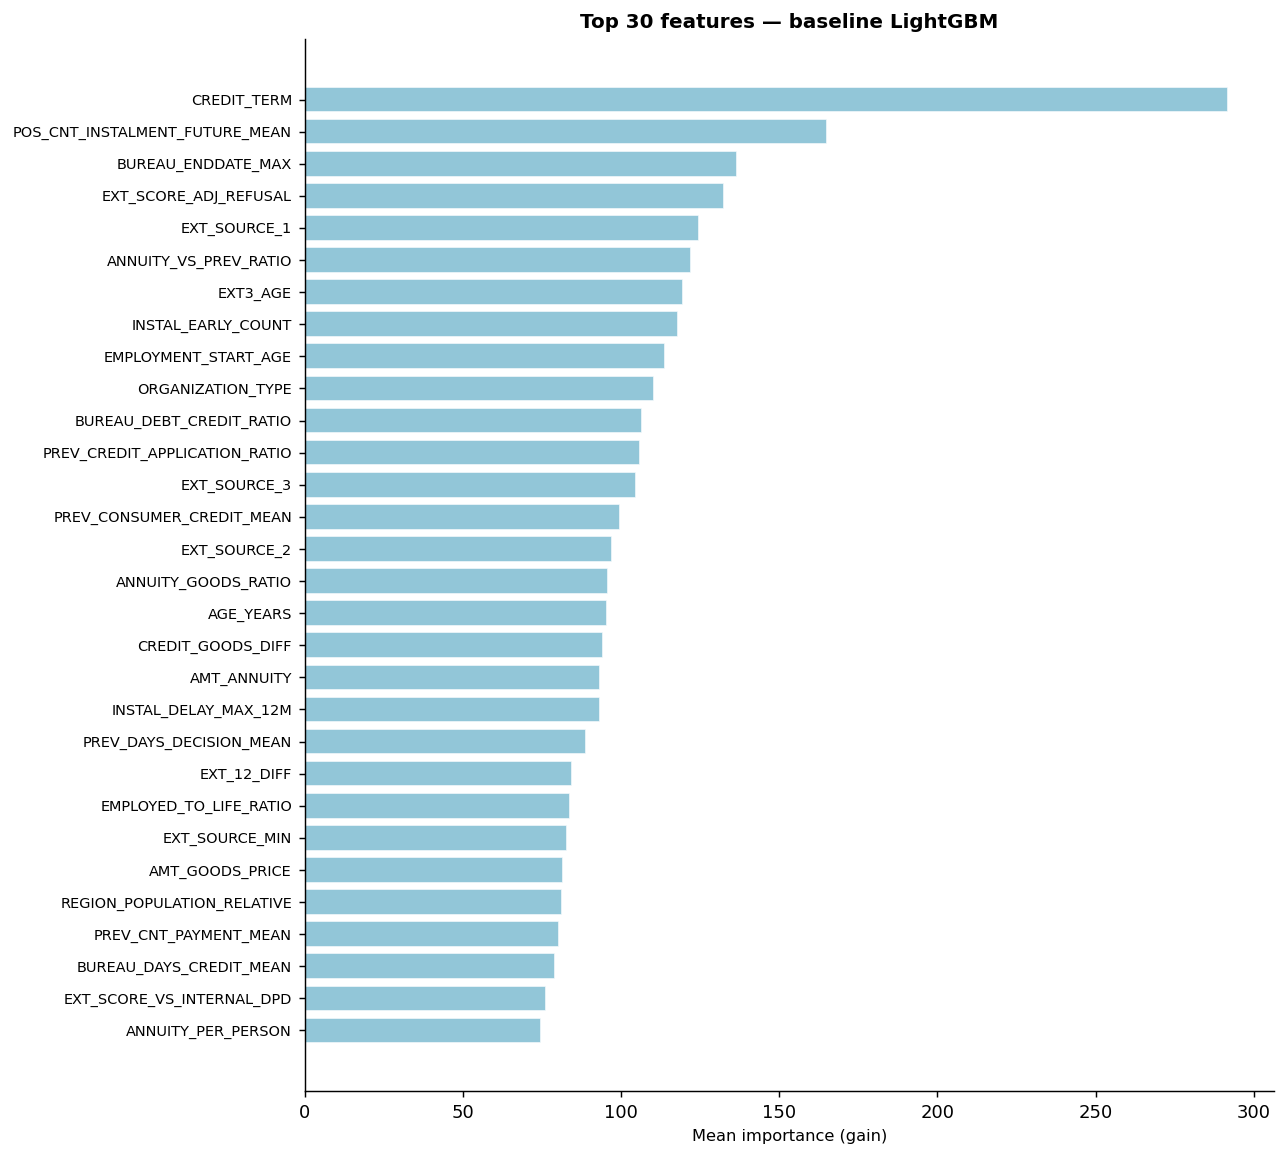


Top 10 features:
                       feature  mean_importance
                   CREDIT_TERM            291.8
POS_CNT_INSTALMENT_FUTURE_MEAN            165.0
            BUREAU_ENDDATE_MAX            136.8
         EXT_SCORE_ADJ_REFUSAL            132.4
                  EXT_SOURCE_1            124.8
         ANNUITY_VS_PREV_RATIO            122.0
                      EXT3_AGE            119.6
            INSTAL_EARLY_COUNT            118.0
          EMPLOYMENT_START_AGE            114.0
             ORGANIZATION_TYPE            110.4


In [11]:
# ── Feature importance plot ───────────────────────────────────────────
feature_importances['mean_importance'] = feature_importances[
    [f'fold_{i}' for i in range(1, N_FOLDS + 1)]
].mean(axis=1)

feature_importances = feature_importances.sort_values(
    'mean_importance', ascending=False
).reset_index(drop=True)

# Top 30
top30 = feature_importances.head(30)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top30['feature'][::-1], top30['mean_importance'][::-1],
        color='#7fbcd2', alpha=0.85, edgecolor='white')
ax.set_xlabel("Mean importance (gain)", fontsize=9)
ax.set_title("Top 30 features — baseline LightGBM",
             fontsize=11, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig("baseline_feature_importance.png", bbox_inches='tight', dpi=150)
plt.show()

print("\nTop 10 features:")
print(feature_importances[['feature', 'mean_importance']].head(10).to_string(index=False))

In [12]:
# ── Zero importance features ──────────────────────────────────────────
zero_importance = feature_importances[
    feature_importances['mean_importance'] == 0
]['feature'].tolist()

print(f"Features with zero importance: {len(zero_importance)}")
if zero_importance:
    print(zero_importance)

Features with zero importance: 20
['CREDIT_EXCEEDS_GOODS', 'IS_NOT_EMPLOYED', 'CC_EVER_LATE', 'EVER_LATE_ANY_PRODUCT', 'FLAG_CONT_MOBILE', 'FLAG_EMP_PHONE', 'POS_EVER_LATE', 'BUREAU_MEAN_DAY_OVERDUE', 'BUREAU_HAS_BAD_DEBT', 'BUREAU_EVER_OVERDUE', 'BBAL_EVER_LATE', 'BBAL_EVER_LATE_3M', 'POS_EVER_LATE_30', 'POS_EVER_LATE_60', 'INSTAL_EVER_LATE', 'HAS_ANY_DOCUMENT', 'INCOME_PENSIONER', 'INSTAL_EVER_UNDERPAID', 'CC_EVER_OVER_LIMIT', 'OVER_LIMIT_AND_LATE']


In [13]:
# ── Feature selection ─────────────────────────────────────────────────
DROP_FEATURES = zero_importance + ['PREV_INTEREST_RATE_MEAN']

FEATURE_COLS_SELECTED = [
    c for c in FEATURE_COLS
    if c not in DROP_FEATURES
]

# Rebuild X and X_test with selected features
X_sel      = X[FEATURE_COLS_SELECTED + TE_COLS].copy()
X_test_sel = X_test[FEATURE_COLS_SELECTED + TE_COLS].copy()

print(f"Features before selection : {len(FEATURE_COLS) + len(TE_COLS)}")
print(f"Features dropped          : {len(DROP_FEATURES)}")
print(f"Features after selection  : {len(FEATURE_COLS_SELECTED) + len(TE_COLS)}")

Features before selection : 266
Features dropped          : 21
Features after selection  : 245


In [14]:
# ── Confirmation CV with selected features ────────────────────────────
# Reruns the same k-fold loop with X_sel instead of X
# to confirm dropping zero-importance features doesn't hurt AUC

oof_preds_sel  = np.zeros(len(X_sel))
fold_aucs_sel  = []

print(f"Confirmation CV — {len(FEATURE_COLS_SELECTED) + len(TE_COLS)} features\n")
print(f"{'Fold':<6} {'AUC':>8}  {'vs baseline':>12}")
print("─" * 32)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_sel, y), 1):

    X_tr, X_val = X_sel.iloc[train_idx].copy(), X_sel.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx],             y.iloc[val_idx]

    X_tr, X_val, _ = target_encode(X_tr, y_tr, X_val, cols=TE_COLS)

    model = lgb.LGBMClassifier(**BASELINE_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    oof_preds_sel[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_preds_sel[val_idx])
    fold_aucs_sel.append(fold_auc)

    delta = fold_auc - fold_aucs[fold - 1]
    print(f"  {fold:<4} {fold_auc:>8.5f}  {delta:>+12.5f}")

oof_auc_sel = roc_auc_score(y, oof_preds_sel)
delta_oof   = oof_auc_sel - oof_auc

print(f"\n{'─' * 32}")
print(f"  OOF AUC (selected) : {oof_auc_sel:.5f}")
print(f"  OOF AUC (baseline) : {oof_auc:.5f}")
print(f"  Delta              : {delta_oof:+.5f}")
print(f"\n{'Proceed to tuning ✓' if delta_oof >= -0.001 else 'Warning — AUC dropped > 0.001, review dropped features'}")

Confirmation CV — 245 features

Fold        AUC   vs baseline
────────────────────────────────
  1     0.78871      +0.00010
  2     0.78387      -0.00027
  3     0.79088      +0.00023
  4     0.78573      +0.00000
  5     0.78562      +0.00024

────────────────────────────────
  OOF AUC (selected) : 0.78692
  OOF AUC (baseline) : 0.78685
  Delta              : +0.00007

Proceed to tuning ✓


## Hyperparameter Tuning — Optuna

Bayesian optimisation with 50 trials on a 20% stratified sample (3-fold CV).
Sampling 20% of the data per trial reduces search time from ~5 hours to ~30
minutes while preserving relative parameter rankings.

Final validation uses the full dataset with 5-fold CV.

**Results:**

| Fold | AUC | vs baseline |
|---|---|---|
| 1 | 0.79121 | +0.00250 |
| 2 | 0.78596 | +0.00209 |
| 3 | 0.79423 | +0.00334 |
| 4 | 0.78933 | +0.00361 |
| 5 | 0.78821 | +0.00259 |
| **OOF AUC** | **0.78968** | **+0.00276** | 

**Progressive improvement summary:**

| Stage | OOF AUC | Delta |
|---|---|---|
| Baseline (266 features) | 0.78685 | — |
| Feature selection (245 features) | 0.78692 | +0.00007 |
| Hyperparameter tuning | 0.78968 | +0.00276 |

The majority of the gain came from hyperparameter tuning (+0.00276).
Feature selection contributed a small but consistent improvement with
the added benefit of a simpler, faster model.

In [15]:
# ── Install Optuna ────────────────────────────────────────────────────
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 23.5 MB/s eta 0:00:00


In [18]:
# Use 20% of train data inside Optuna trials — fast proxy for full AUC
# Final 5-fold CV always runs on full data
SAMPLE_IDX = np.random.RandomState(42).choice(
    len(X_sel), size=int(len(X_sel) * 0.2), replace=False
)
X_sel_sample = X_sel.iloc[SAMPLE_IDX].reset_index(drop=True)
y_sample     = y.iloc[SAMPLE_IDX].reset_index(drop=True)

def objective(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'scale_pos_weight':  SCALE_POS_WEIGHT,
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 1.0),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample_freq':    trial.suggest_int('subsample_freq', 1, 10),
        'learning_rate':     0.05,
        'n_estimators':      500,    # lower cap — faster trials
    }

    skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_aucs_trial = []

    for train_idx, val_idx in skf_opt.split(X_sel_sample, y_sample):
        X_tr  = X_sel_sample.iloc[train_idx].copy()
        X_val = X_sel_sample.iloc[val_idx].copy()
        y_tr  = y_sample.iloc[train_idx]
        y_val = y_sample.iloc[val_idx]

        X_tr, X_val, _ = target_encode(X_tr, y_tr, X_val, cols=TE_COLS)

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )
        fold_aucs_trial.append(
            roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
        )

    return np.mean(fold_aucs_trial)

# Rerun study with 50 trials on 20% sample
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUC (sampled 3-fold) : {study.best_value:.5f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:<25}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC (sampled 3-fold) : 0.77494
Best params:
  num_leaves               : 20
  max_depth                : 10
  min_child_samples        : 71
  reg_alpha                : 7.053108018533752
  reg_lambda               : 8.883862381393653
  min_split_gain           : 0.7026992327579986
  subsample                : 0.6422284320908205
  colsample_bytree         : 0.5055232823774823
  subsample_freq           : 10


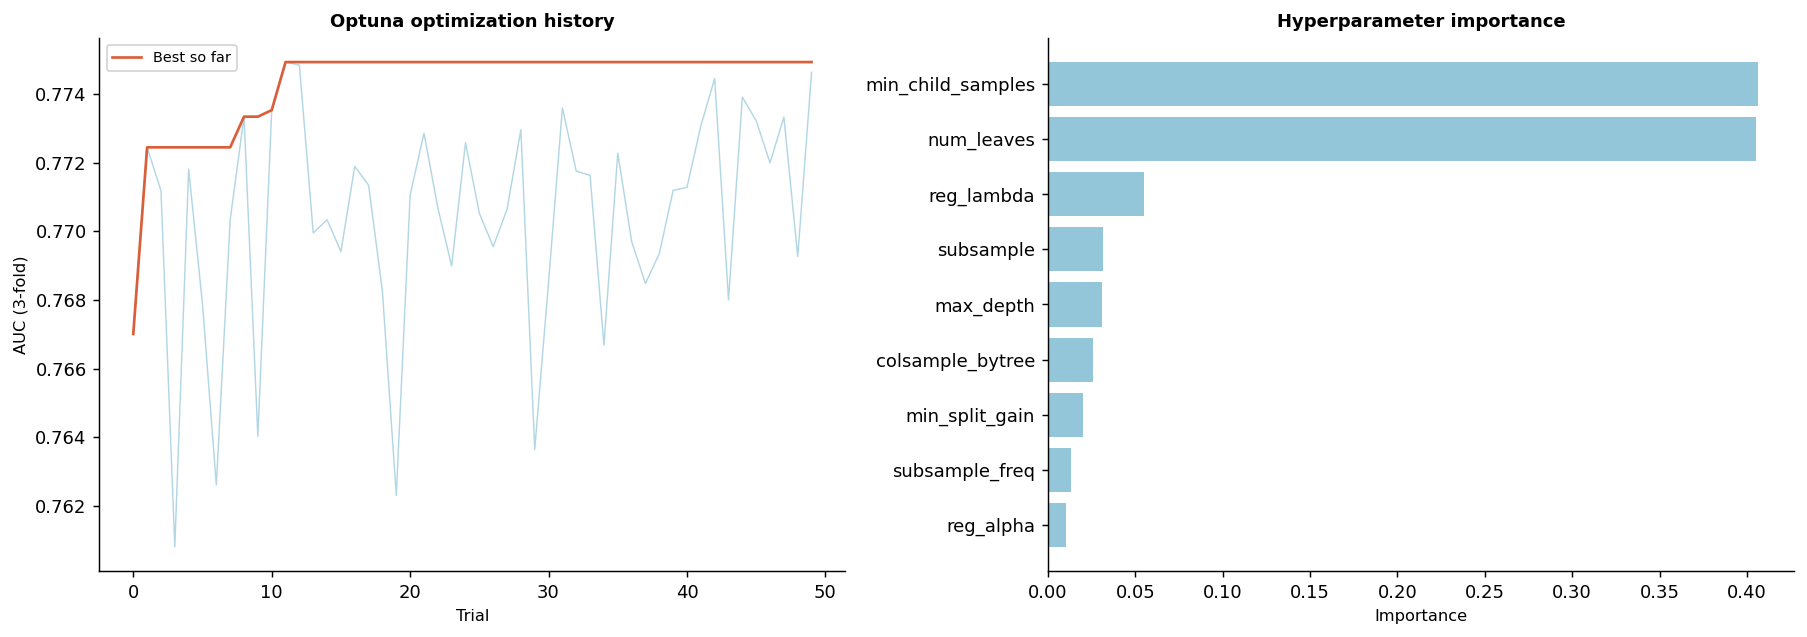

In [19]:
# ── Optuna results plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'],
             color='#7fbcd2', linewidth=0.8, alpha=0.6)
axes[0].plot(trials_df['number'],
             trials_df['value'].cummax(),
             color='#d95f3b', linewidth=1.5, label='Best so far')
axes[0].set_xlabel("Trial", fontsize=9)
axes[0].set_ylabel("AUC (3-fold)", fontsize=9)
axes[0].set_title("Optuna optimization history", fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8)

# Parameter importance
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys())[::-1],
             list(importances.values())[::-1],
             color='#7fbcd2', alpha=0.85)
axes[1].set_xlabel("Importance", fontsize=9)
axes[1].set_title("Hyperparameter importance", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("optuna_results.png", bbox_inches='tight', dpi=150)
plt.show()

In [20]:
# ── Final CV with best params ─────────────────────────────────────────
# Rerun full 5-fold with tuned params to get reliable AUC estimate

TUNED_PARAMS = {
    'objective':        'binary',
    'metric':           'auc',
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
    'learning_rate':    0.05,
    'n_estimators':     2000,     # higher — early stopping will find optimum
    **study.best_params
}

oof_preds_tuned  = np.zeros(len(X_sel))
test_preds_tuned = np.zeros(len(X_test_sel))
fold_aucs_tuned  = []

print(f"Final 5-fold CV with tuned params\n")
print(f"{'Fold':<6} {'AUC':>8}  {'vs selected baseline':>22}")
print("─" * 42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_sel, y), 1):

    X_tr  = X_sel.iloc[train_idx].copy()
    X_val = X_sel.iloc[val_idx].copy()
    y_tr  = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    X_tr, X_val, te_enc = target_encode(X_tr, y_tr, X_val, cols=TE_COLS)

    model = lgb.LGBMClassifier(**TUNED_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    oof_preds_tuned[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_preds_tuned[val_idx])
    fold_aucs_tuned.append(fold_auc)

    # Test predictions
    X_test_enc = X_test_sel.copy()
    for col in TE_COLS:
        X_test_enc[col] = X_test_enc[col].map(
            te_enc[col]['mapping']
        ).fillna(te_enc[col]['global_mean'])
    test_preds_tuned += model.predict_proba(X_test_enc)[:, 1] / N_FOLDS

    delta = fold_auc - fold_aucs_sel[fold - 1]
    print(f"  {fold:<4} {fold_auc:>8.5f}  {delta:>+22.5f}")

oof_auc_tuned = roc_auc_score(y, oof_preds_tuned)
print(f"\n{'─' * 42}")
print(f"  OOF AUC (tuned)    : {oof_auc_tuned:.5f}")
print(f"  OOF AUC (baseline) : {oof_auc_sel:.5f}")
print(f"  Delta              : {oof_auc_tuned - oof_auc_sel:+.5f}")

Final 5-fold CV with tuned params

Fold        AUC    vs selected baseline
──────────────────────────────────────────
  1     0.79121                +0.00250
  2     0.78596                +0.00209
  3     0.79423                +0.00334
  4     0.78933                +0.00361
  5     0.78821                +0.00259

──────────────────────────────────────────
  OOF AUC (tuned)    : 0.78968
  OOF AUC (baseline) : 0.78692
  Delta              : +0.00276


## Model Interpretation — SHAP Analysis

SHAP (SHapley Additive exPlanations) assigns each feature a contribution
value for every individual prediction. Positive SHAP = pushes toward default,
negative SHAP = pushes away from default. Color encodes feature value:
red = high, blue = low.

---

### Key findings from the SHAP Summary Plot

**The two most important features are engineered cross-table features —
not raw data columns.** This is the direct return on investment of the
feature engineering phase.

**`EXT_SCORE_VS_INTERNAL_DPD` — #1**  
Combines external credit score with internal DPD history. Low values push
strongly toward default. The wide horizontal spread confirms it is the single
most discriminating feature in the model.

**`EXT_SCORE_ADJ_REFUSAL` — #2**  
Adjusts the external score downward based on HC's own refusal history.
Same direction as above — low values signal high risk.

**`IS_MALE` — #3**  
Males (red) carry higher default risk than females (blue) in this dataset,
consistent with credit risk literature. Clean binary separation.

**`EXT_SOURCE_MEAN` — #4**  
Low external scores consistently predict default. Tight spread indicates
uniform predictive power across all client segments.

**`CREDIT_TERM` — #6**  
Shows a non-linear U-shape: both very short and very long loan terms
increase default risk, with the safest clients in the middle range.
A logistic regression would miss this relationship entirely — one of the
key advantages of gradient boosting on tabular data.

**`ANNUITY_VS_PREV_RATIO` — #8**  
High values (current annuity much higher than historical average) push
toward default — clients overextending relative to their past behaviour.
Designed specifically to capture this cross-table signal.

**`INSTAL_DELAY_MAX_12M` — #22**  
High recent delays push strongly toward default. The 12-month recency
window is more predictive than the full historical average, confirming
that recent behaviour outweighs distant history.

**`POS_MONTHS_COUNT` — #19 (grey)**  
Mostly grey — missing for clients with no POS history. LightGBM uses
the missingness itself as a split criterion, making NULL informative
rather than problematic.

---

### Three takeaways for business stakeholders

1. **All SHAP directions are consistent with credit risk domain knowledge** —
   higher external scores reduce risk, more debt relative to income increases
   risk, higher education reduces risk. A model where SHAP directions
   contradict domain knowledge would indicate data leakage or a bug.

2. **Individual predictions are fully explainable** — the waterfall plots
   show exactly which features drove the model's decision for any specific
   client, enabling actionable feedback to loan officers.

3. **The model captures non-linear relationships** that rule-based scorecards
   and logistic regression models miss — particularly the interaction between
   external scores and internal behaviour history.## SHAP

In [21]:
!pip install shap -q
import shap

In [22]:
# ── Train a single model on full train for SHAP ───────────────────────
# SHAP on the full 5-fold ensemble is complex — we use a single model
# trained on 80% of data for interpretation purposes.
# This is standard practice — SHAP is for explanation, not evaluation.

from sklearn.model_selection import train_test_split

X_shap_tr, X_shap_val, y_shap_tr, y_shap_val = train_test_split(
    X_sel, y, test_size=0.2, random_state=42, stratify=y
)

# Target encode on this split
X_shap_tr, X_shap_val, te_shap = target_encode(
    X_shap_tr, y_shap_tr, X_shap_val, cols=TE_COLS
)

shap_model = lgb.LGBMClassifier(**TUNED_PARAMS)
shap_model.fit(
    X_shap_tr, y_shap_tr,
    eval_set=[(X_shap_val, y_shap_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

shap_auc = roc_auc_score(y_shap_val,
                          shap_model.predict_proba(X_shap_val)[:, 1])
print(f"Single model AUC (80/20 split): {shap_auc:.5f}")

Single model AUC (80/20 split): 0.79113


In [23]:
# ── Compute SHAP values ───────────────────────────────────────────────
# Sample 5000 rows for speed — sufficient for reliable SHAP estimates

SHAP_SAMPLE = 5000
shap_sample_idx = np.random.RandomState(42).choice(
    len(X_shap_val), size=min(SHAP_SAMPLE, len(X_shap_val)), replace=False
)
X_shap_sample = X_shap_val.iloc[shap_sample_idx]

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap_sample)

# LightGBM binary returns list [neg_class, pos_class] — take positive class
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values computed — shape: {shap_values.shape}")

SHAP values computed — shape: (5000, 245)


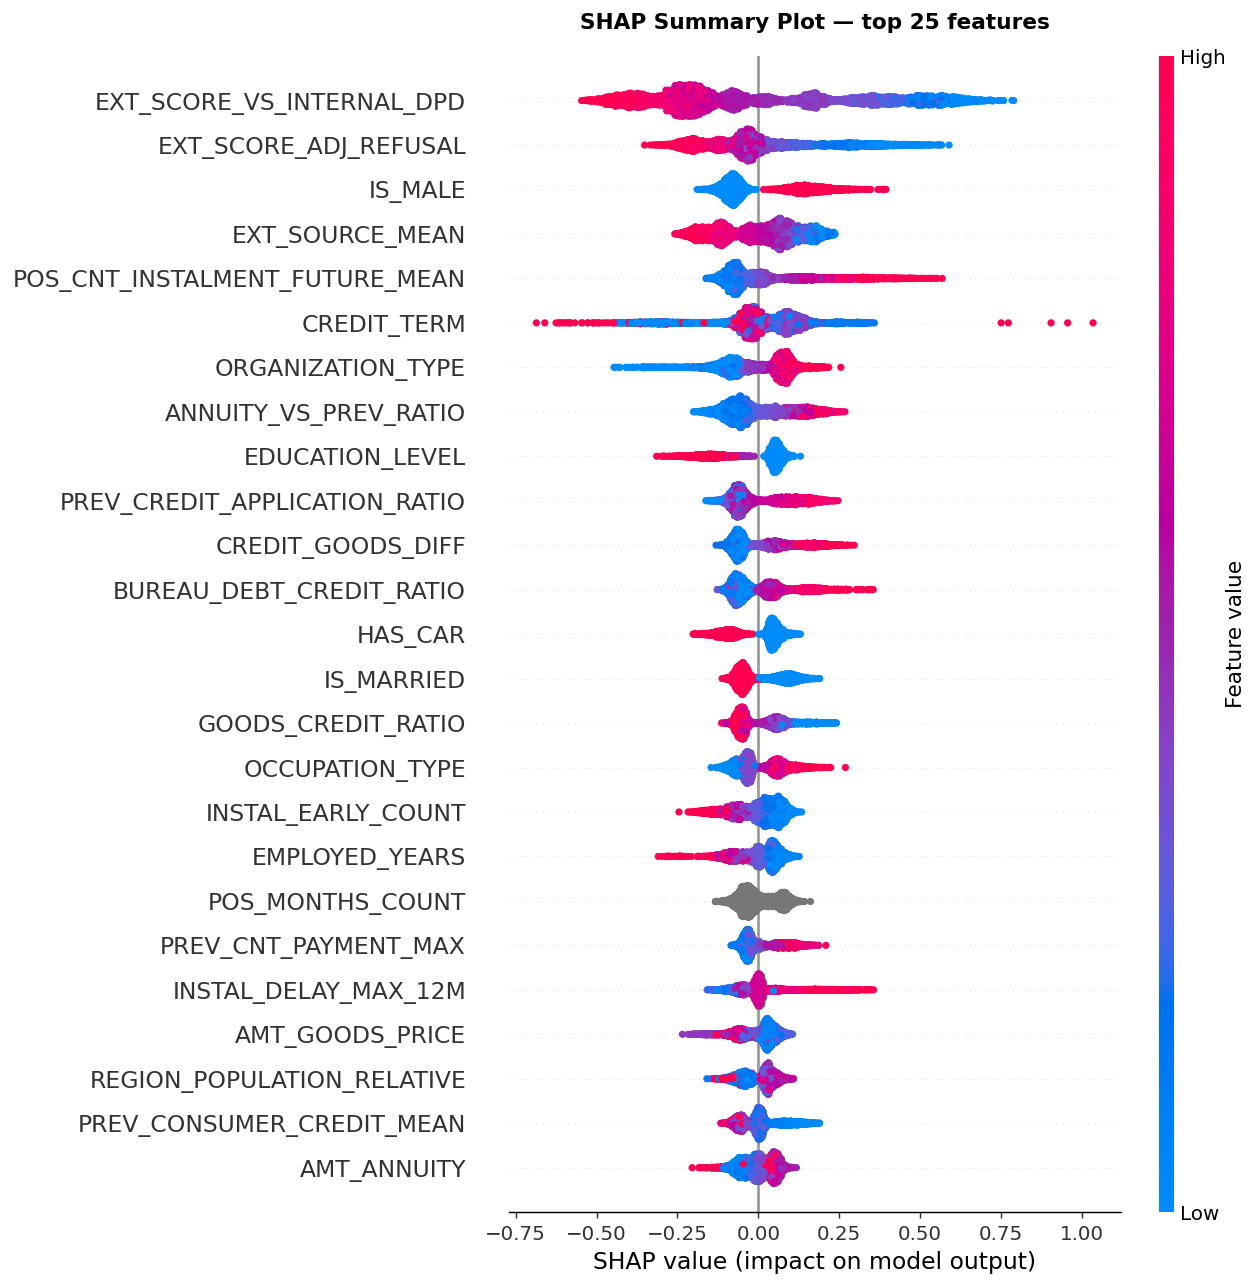

In [24]:
# ── Plot 1 — SHAP summary plot (beeswarm) ────────────────────────────
# Best plot for a portfolio — shows both importance AND direction of effect
# Red = high feature value, Blue = low feature value
# X axis = impact on model output (positive = pushes toward default)

plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values,
    X_shap_sample,
    max_display=25,
    show=False,
    plot_size=None
)
plt.title("SHAP Summary Plot — top 25 features",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches='tight', dpi=150)
plt.show()

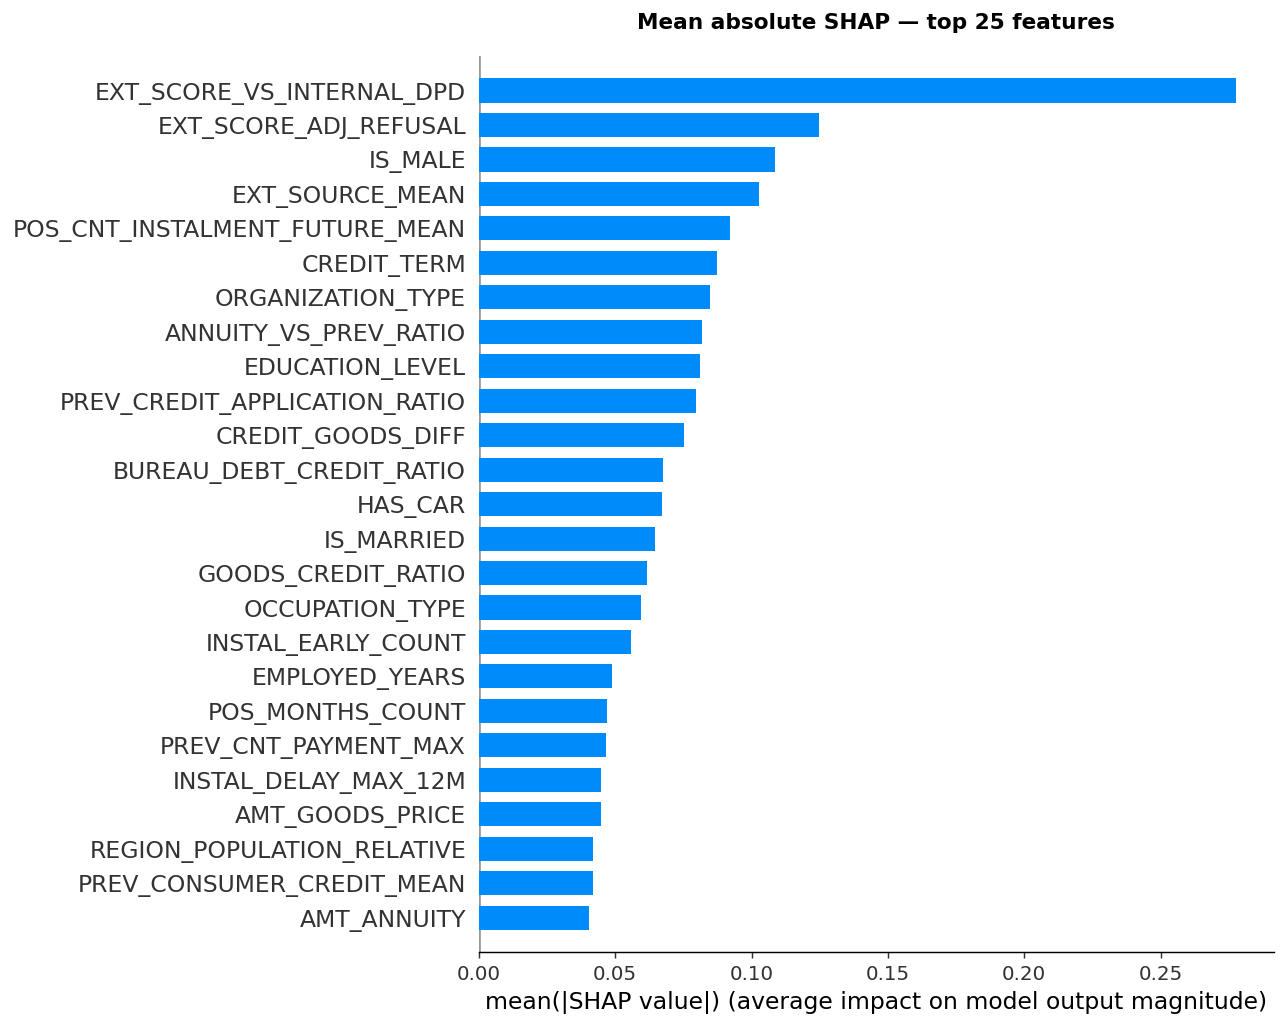

In [25]:
# ── Plot 2 — SHAP bar plot (mean absolute SHAP) ───────────────────────
# Clean version for presentations — pure importance ranking

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_shap_sample,
    plot_type='bar',
    max_display=25,
    show=False,
    plot_size=None
)
plt.title("Mean absolute SHAP — top 25 features",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_bar.png", bbox_inches='tight', dpi=150)
plt.show()

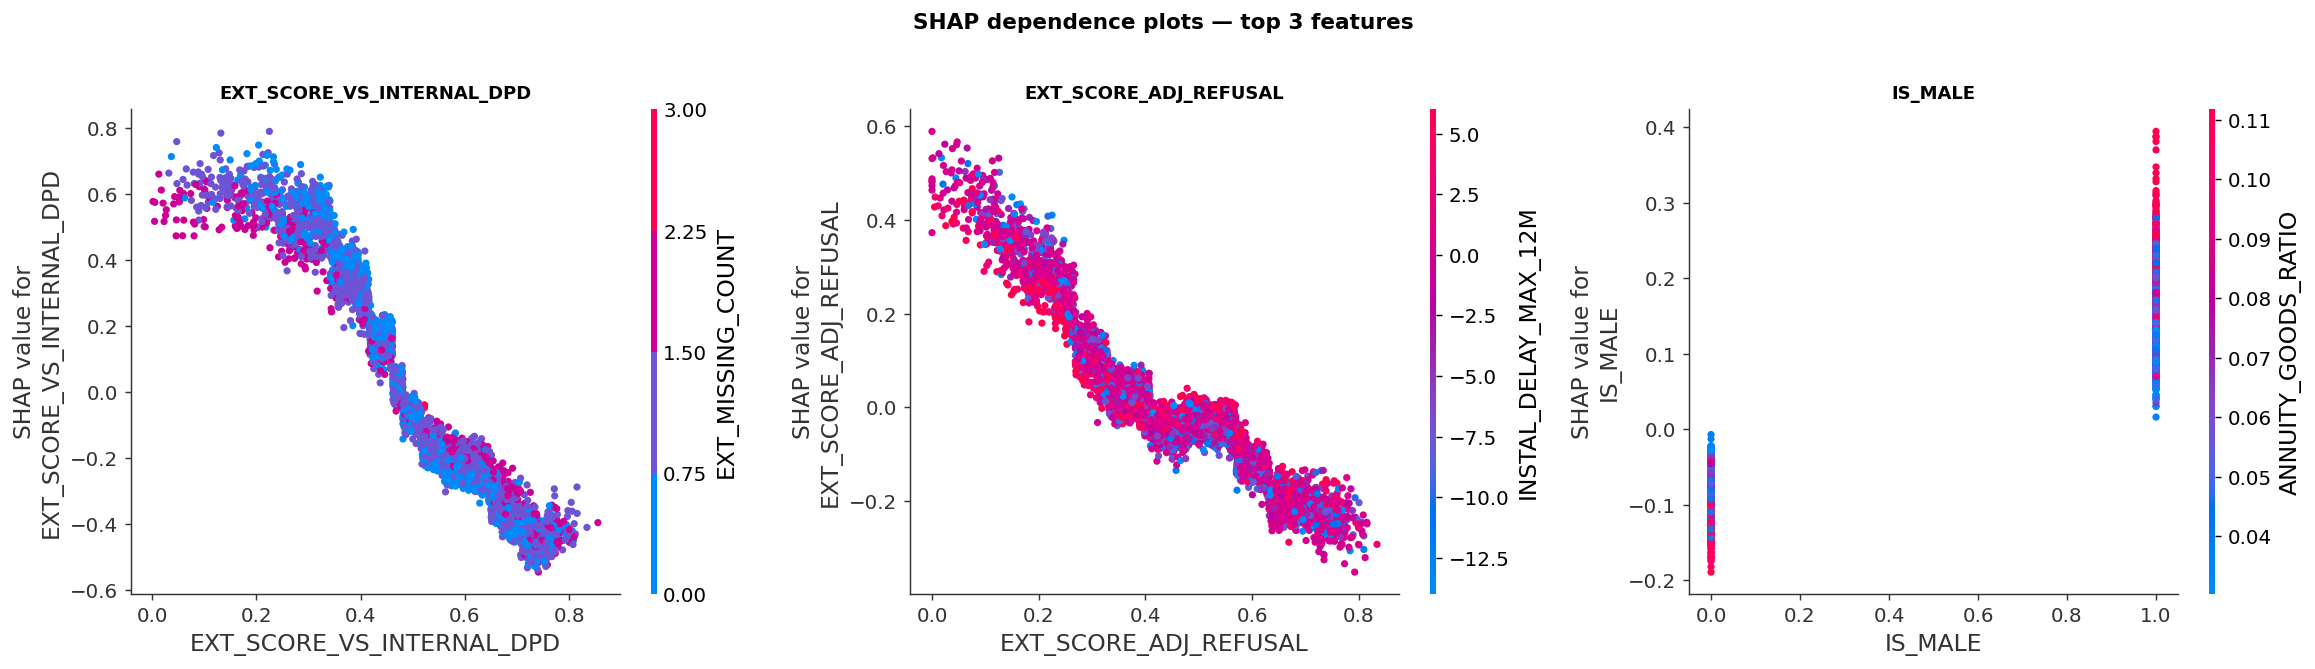

In [30]:
# ── Plot 3 — SHAP dependence plots for top 3 features ────────────────
# Shows the non-linear relationship between feature value and its SHAP value
# The color dimension shows interaction with the most correlated feature

# Robust handling for potential 'NAType' errors in SHAP plots.
# The error "TypeError: float() argument must be a string or a real number, not 'NAType'"
# indicates that pandas.NaT values are still present in X_shap_sample when SHAP tries
# to convert values to float. This can happen if NaT values exist in object columns
# or if previous coercion methods weren't fully effective in all cases.

# Step 1: Explicitly replace all pandas.NaT values with numpy.nan
# This ensures that any 'Not a Time' values are converted to standard missing numerical values.
X_shap_sample = X_shap_sample.replace({pd.NaT: np.nan})

# Step 2: Convert all columns to float if they are numeric.
# This is crucial to ensure that all numerical columns can handle potential float medians
# and np.nan values, preventing the TypeError with Int64Dtype.
for col in X_shap_sample.columns:
    # Check if the column is already numeric (int, float, etc.) or if it can be converted to numeric.
    if pd.api.types.is_numeric_dtype(X_shap_sample[col]):
        # Convert to float. This will convert any integer dtype (like int64 or Int64) to float64,
        # and `pd.NA` will become `np.nan`.
        X_shap_sample[col] = X_shap_sample[col].astype(float)
    else:
        # If it's an object column or other non-numeric, try to convert it to numeric.
        # This will convert strings representing numbers to floats and non-convertible values to NaN.
        X_shap_sample[col] = pd.to_numeric(X_shap_sample[col], errors='coerce')

# Step 3: Fill any remaining NaN values with the median.
# Now that all numeric columns are float dtype, this operation should be safe.
X_shap_sample = X_shap_sample.fillna(X_shap_sample.median())

top3_features = pd.DataFrame({
    'feature':    X_shap_sample.columns,
    'mean_shap':  np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, top3_features):
    feat_idx = list(X_shap_sample.columns).index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_shap_sample, # Use the cleaned X_shap_sample here
        ax=ax,
        show=False
    )
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("SHAP dependence plots — top 3 features",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("shap_dependence.png", bbox_inches='tight', dpi=150)
plt.show()

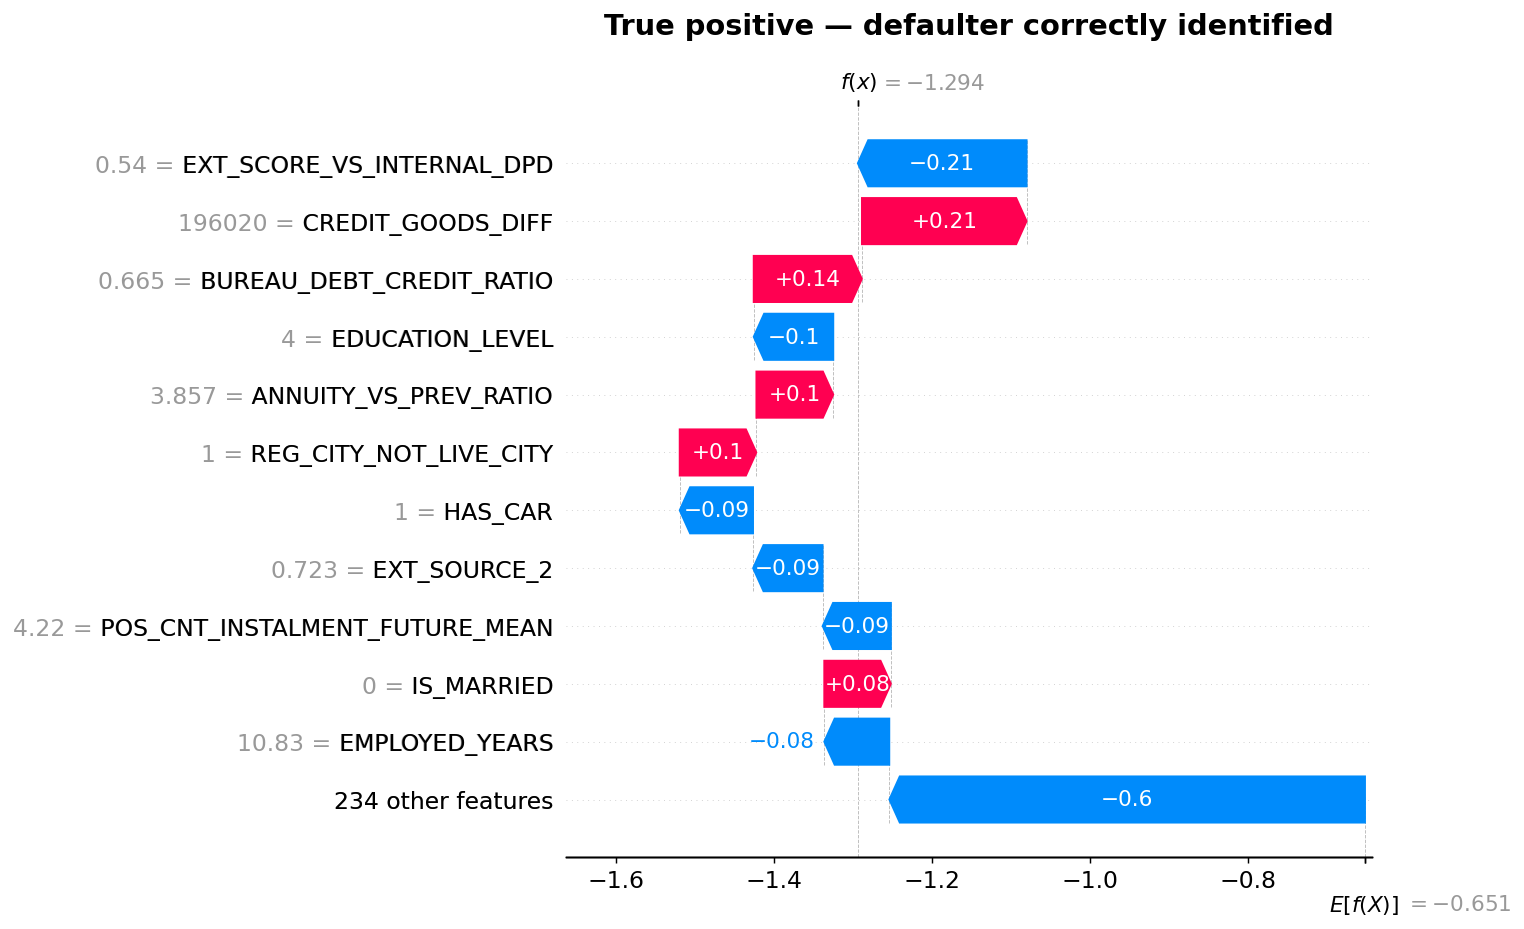

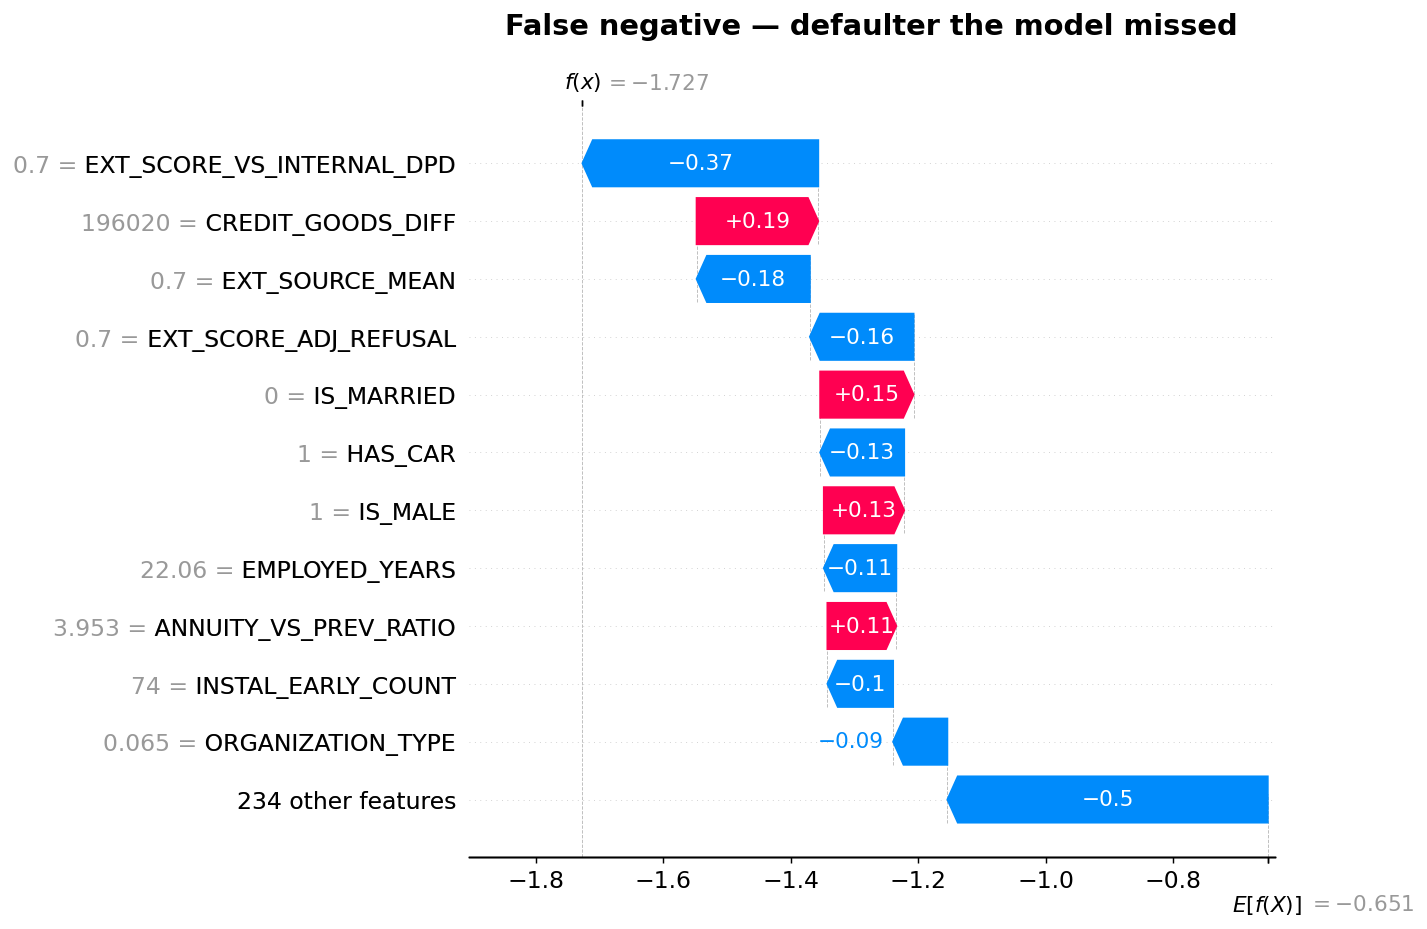

In [37]:
# ── Plot 4 — Waterfall plots (local explanation) ──────────────────────
# Shows why the model predicted default/no-default for specific clients
import matplotlib.pyplot as plt
import shap
import pandas as pd

# 1. Setup of the results
val_results = pd.DataFrame({
    'true':  y_shap_val.values,
    'pred':  shap_model.predict_proba(X_shap_val)[:, 1],
    'idx':   range(len(y_shap_val))
})

# True positive — high predicted probability + actual default
tp_idx = val_results[
    (val_results['true'] == 1) &
    (val_results['pred'] > 0.7)
].iloc[0]['idx']

# False negative — low predicted probability + actual default
fn_idx = val_results[
    (val_results['true'] == 1) &
    (val_results['pred'] < 0.2)
].iloc[0]['idx']

# 2. Cleaning of the feature names (troncati a 35 caratteri)
clean_feature_names = [
    f[:32] + '...' if len(f) > 35 else f
    for f in X_shap_sample.columns
]

# 3. base_value management
base_val = explainer.expected_value
if isinstance(base_val, list) or isinstance(base_val, np.ndarray):
    base_val = base_val[1]

# ─── Plot 1: True Positive ──────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap_exp_tp = shap.Explanation(
    values        = shap_values[int(tp_idx)],
    base_values   = base_val,
    data          = X_shap_sample.iloc[int(tp_idx)].values,
    feature_names = clean_feature_names
)
shap.waterfall_plot(shap_exp_tp, max_display=12, show=False)
plt.title("True positive — defaulter correctly identified", fontsize=16, fontweight='bold', pad=20)
plt.savefig("shap_waterfall_TP.png", bbox_inches='tight', dpi=150)
plt.show()
plt.close()

# ─── Plot 2: False Negative ─────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap_exp_fn = shap.Explanation(
    values        = shap_values[int(fn_idx)],
    base_values   = base_val,
    data          = X_shap_sample.iloc[int(fn_idx)].values,
    feature_names = clean_feature_names
)
shap.waterfall_plot(shap_exp_fn, max_display=12, show=False)
plt.title("False negative — defaulter the model missed", fontsize=16, fontweight='bold', pad=20)
plt.savefig("shap_waterfall_FN.png", bbox_inches='tight', dpi=150)
plt.show()
plt.close()